# Práctica 2 — Análisis Exploratorio de Datos con Python
**Universidad de San Carlos de Guatemala — ECFM**  
**Programación 1**  
**Estudiante:** Abraham Vallejo  
**Carnet:** 202108790

---
Este notebook realiza un análisis exploratorio de datos (EDA) sobre el **Stars Dataset** de Kaggle,
que contiene 1 000 estrellas con 28 clases espectrales distintas.

---
## Sección 1 — Configuración del ambiente y carga de datos (20 pts)

In [1]:
# ── 1. Importar librerías con sus alias convencionales ───────────────── (5 pts)
# Documentación:
#   NumPy  → https://numpy.org/doc/stable/reference/
#   Pandas → https://pandas.pydata.org/docs/reference/
#   Matplotlib → https://matplotlib.org/stable/api/pyplot_summary.html
#   Seaborn    → https://seaborn.pydata.org/api.html

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías importadas correctamente.")
print(f"  numpy   {np.__version__}")
print(f"  pandas  {pd.__version__}")
print(f"  seaborn {sns.__version__}")

Librerías importadas correctamente.
  numpy   2.0.2
  pandas  2.2.2
  seaborn 0.13.2


In [7]:
stars = pd.read_csv("star_dataset.csv")

print(f"Dataset cargado exitosamente: {len(stars)} filas.")

Dataset cargado exitosamente: 1000 filas.


In [8]:
# ── 3. Mostrar las primeras filas con stars.head() ───────────────────── (5 pts)
# Documentación: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html

stars.head()

,Name,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K),Spectral Class
0,Beta Orionis 95,1103.16,267408.05361,17.3647,46767.0,O5V
1,Iota Centauri 76,1690.12,51489.86097,8.8746,37032.1,O8V
2,Alpha Virginis 26,2865.27,38052.99894,6.6781,30695.3,B0V
3,Epsilon Orionis 98,3224.09,7886.97576,4.3506,22932.9,B2V
4,Zeta Centauri 12,1522.31,1525.65258,3.0159,17587.1,B5V


In [9]:
# ── 4. Verificar dimensiones y tipos de datos ────────────────────────── (5 pts)
# Documentación shape:  https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html
# Documentación dtypes: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html

print("Dimensiones del dataset (filas, columnas):")
print(stars.shape)

print("\nTipos de datos por columna:")
print(stars.dtypes)

Dimensiones del dataset (filas, columnas):
(1000, 6)

Tipos de datos por columna:
Name                  object
Distance (ly)        float64
Luminosity (L/Lo)    float64
Radius (R/Ro)        float64
Temperature (K)      float64
Spectral Class        object
dtype: object


---
## Sección 2 — Exploración estadística y comparación de técnicas (35 pts)

In [10]:
# ── 1. Estadísticas descriptivas con stars.describe() ───────────────── (5 pts)
# Documentación: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html

stars.describe()

,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,2028.108450,18707.087784,2.194339,10548.107700
std,1155.455505,85597.559030,3.311288,10688.510389
min,5.350000,0.000080,0.066700,2001.900000
25%,1024.012500,0.145435,0.604150,4440.550000
50%,2071.425000,1.246810,0.987400,6135.800000
75%,3004.230000,28.449870,1.837450,9530.550000
max,3999.910000,774181.398780,19.985900,49823.800000


In [11]:
# ── 2. Verificar valores nulos ───────────────────────────────────────── (4 pts)
# Documentación: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html

print("Valores nulos por columna:")
print(stars.isnull().sum())
print("\nNo hay valores nulos en el dataset." if stars.isnull().sum().sum() == 0
      else "\n⚠ Hay valores nulos que requieren tratamiento.")

Valores nulos por columna:
Name                 0
Distance (ly)        0
Luminosity (L/Lo)    0
Radius (R/Ro)        0
Temperature (K)      0
Spectral Class       0
dtype: int64

No hay valores nulos en el dataset.


In [12]:
# ── 3. Contar estrellas por clase espectral con value_counts() ───────── (4 pts)
# Documentación: https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html

conteo_clases = stars["Spectral Class"].value_counts()
print("Cantidad de estrellas por clase espectral:")
print(conteo_clases)

Cantidad de estrellas por clase espectral:
Spectral Class
O5V      36
O8V      36
B0V      36
B2V      36
B5V      36
B8V      36
A0V      36
A2V      36
A5V      36
A7V      36
F0V      36
F2V      36
F5V      36
F8V      36
G0V      36
G2V      36
G5V      36
G8V      36
K0V      36
K2V      36
K5V      35
K8V      35
M0V      35
M2V      35
M3.5V    35
M5V      35
M8V      35
M9V      35
Name: count, dtype: int64


In [13]:
# ── 4. Temperatura media de clase A7V con ciclo for ──────────────────── (8 pts)
# Se filtra el DataFrame para la clase A7V, luego se recorre la columna
# acumulando la suma y se divide entre el conteo.

# Filtrar el DataFrame para la clase espectral A7V
stars_a7v = stars[stars["Spectral Class"] == "A7V"]

# Recorrer la columna y acumular la suma de temperaturas
suma_temp = 0
conteo = 0
for temp in stars_a7v["Temperature (K)"]:
    suma_temp += temp
    conteo += 1

# Calcular la media
media_a7v_for = suma_temp / conteo

print(f"Estrellas de clase A7V: {conteo}")
print(f"Temperatura media (ciclo for): {media_a7v_for:.2f} K")

Estrellas de clase A7V: 36
Temperatura media (ciclo for): 7921.23 K


In [14]:
# ── 5. Temperatura promedio por clase con groupby().mean() ───────────── (6 pts)
# Documentación: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html

# Una sola línea reemplaza el ciclo for completo para TODAS las clases
media_por_clase = stars.groupby("Spectral Class")["Temperature (K)"].mean()

print("Temperatura media (K) por clase espectral (groupby):")
print(media_por_clase)

# Comparación con el resultado del ciclo for
media_a7v_groupby = media_por_clase["A7V"]
print(f"\n── Comparación para A7V ──")
print(f"  Ciclo for : {media_a7v_for:.2f} K")
print(f"  groupby   : {media_a7v_groupby:.2f} K")
print(f"  Diferencia: {abs(media_a7v_for - media_a7v_groupby):.10f} K (≈ 0, mismo resultado)")

Temperatura media (K) por clase espectral (groupby):
Spectral Class
A0V      10748.800000
A2V       9113.033333
A5V       8470.466667
A7V       7921.225000
B0V      31128.541667
B2V      24616.958333
B5V      18894.416667
B8V      13853.244444
F0V       7426.055556
F2V       7053.911111
F5V       6688.722222
F8V       6293.547222
G0V       6015.833333
G2V       5803.297222
G5V       5592.836111
G8V       5401.252778
K0V       5184.416667
K2V       4958.702778
K5V       4566.780000
K8V       4234.362857
M0V       3976.325714
M2V       3715.725714
M3.5V     3347.631429
M5V       3021.097143
M8V       2591.985714
M9V       2183.871429
O5V      44705.863889
O8V      36261.802778
Name: Temperature (K), dtype: float64

── Comparación para A7V ──
  Ciclo for : 7921.23 K
  groupby   : 7921.22 K
  Diferencia: 0.0000000000 K (≈ 0, mismo resultado)


In [15]:
# ── 6. NumPy: media, mediana y desviación estándar de temperatura ────── (4 pts)
# Documentación:
#   np.mean   → https://numpy.org/doc/stable/reference/generated/numpy.mean.html
#   np.median → https://numpy.org/doc/stable/reference/generated/numpy.median.html
#   np.std    → https://numpy.org/doc/stable/reference/generated/numpy.std.html

temperaturas = stars["Temperature (K)"].values

media_np   = np.mean(temperaturas)
mediana_np = np.median(temperaturas)
std_np     = np.std(temperaturas)

print("Estadísticas de Temperature (K) con NumPy:")
print(f"  Media            : {media_np:.2f} K")
print(f"  Mediana          : {mediana_np:.2f} K")
print(f"  Desv. estándar   : {std_np:.2f} K")

Estadísticas de Temperature (K) con NumPy:
  Media            : 10548.11 K
  Mediana          : 6135.80 K
  Desv. estándar   : 10683.16 K


In [16]:
# ── 7. NumPy: percentiles 25, 50, 75 y 90 del radio estelar ─────────── (4 pts)
# Documentación: https://numpy.org/doc/stable/reference/generated/numpy.percentile.html

radios = stars["Radius (R/Ro)"].values

percentiles = np.percentile(radios, [25, 50, 75, 90])

print("Percentiles del radio estelar R/R☉ (NumPy):")
for p, v in zip([25, 50, 75, 90], percentiles):
    print(f"  Percentil {p:2d}: {v:.4f} R/R☉")

Percentiles del radio estelar R/R☉ (NumPy):
  Percentil 25: 0.6041 R/R☉
  Percentil 50: 0.9874 R/R☉
  Percentil 75: 1.8375 R/R☉
  Percentil 90: 5.9276 R/R☉


---
## Sección 3 — Visualizaciones (30 pts)

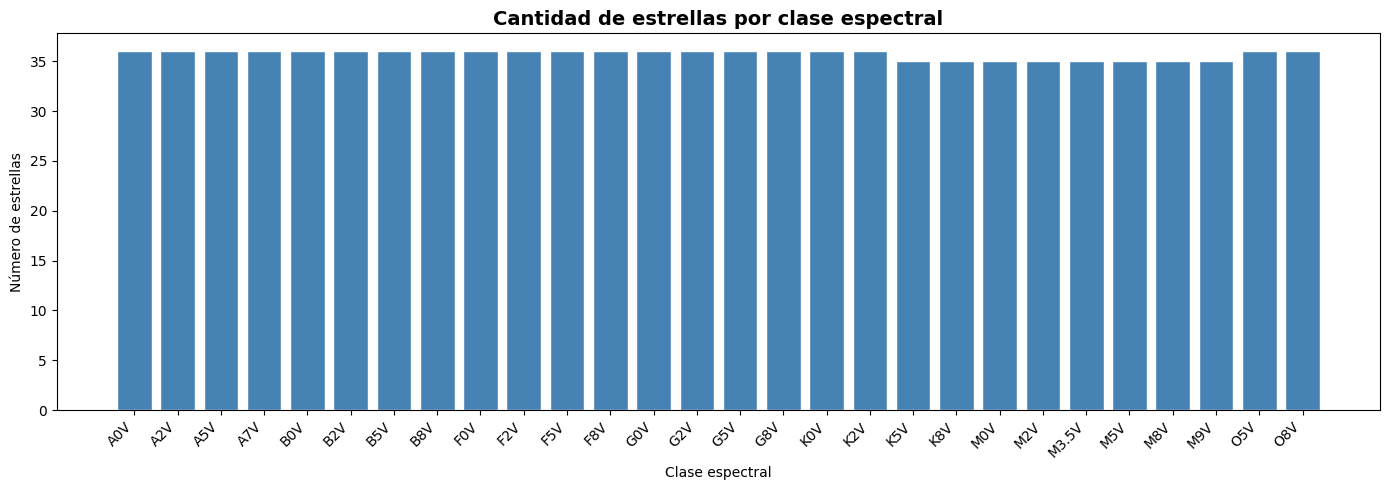

In [17]:
# ── Gráfica 1: Cantidad de estrellas por clase espectral (barras) ────── (7 pts)
# Documentación pyplot.bar: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

conteo_ordenado = stars["Spectral Class"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(conteo_ordenado.index, conteo_ordenado.values, color="steelblue", edgecolor="white")
plt.title("Cantidad de estrellas por clase espectral", fontsize=14, fontweight="bold")
plt.xlabel("Clase espectral")
plt.ylabel("Número de estrellas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_9779/1840141248.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


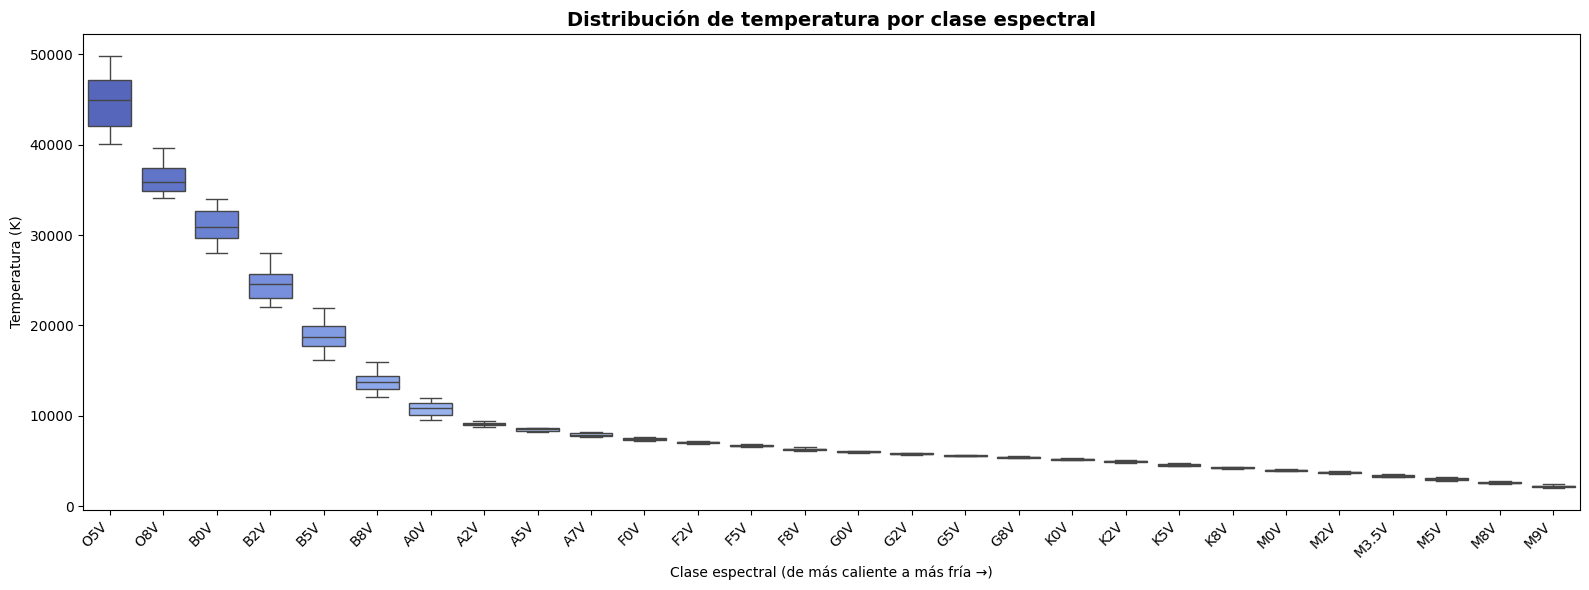

In [18]:
# ── Gráfica 2: Boxplot — Temperatura por clase espectral ─────────────── (8 pts)
# Documentación: https://seaborn.pydata.org/generated/seaborn.boxplot.html

# Ordenar las clases espectrales para que aparezcan de caliente a fría
orden_espectral = [
    'O5V','O8V','B0V','B2V','B5V','B8V',
    'A0V','A2V','A5V','A7V',
    'F0V','F2V','F5V','F8V',
    'G0V','G2V','G5V','G8V',
    'K0V','K2V','K5V','K8V',
    'M0V','M2V','M3.5V','M5V','M8V','M9V'
]

plt.figure(figsize=(16, 6))
sns.boxplot(
    data=stars,
    x="Spectral Class",
    y="Temperature (K)",
    order=orden_espectral,
    palette="coolwarm"
)
plt.title("Distribución de temperatura por clase espectral", fontsize=14, fontweight="bold")
plt.xlabel("Clase espectral (de más caliente a más fría →)")
plt.ylabel("Temperatura (K)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

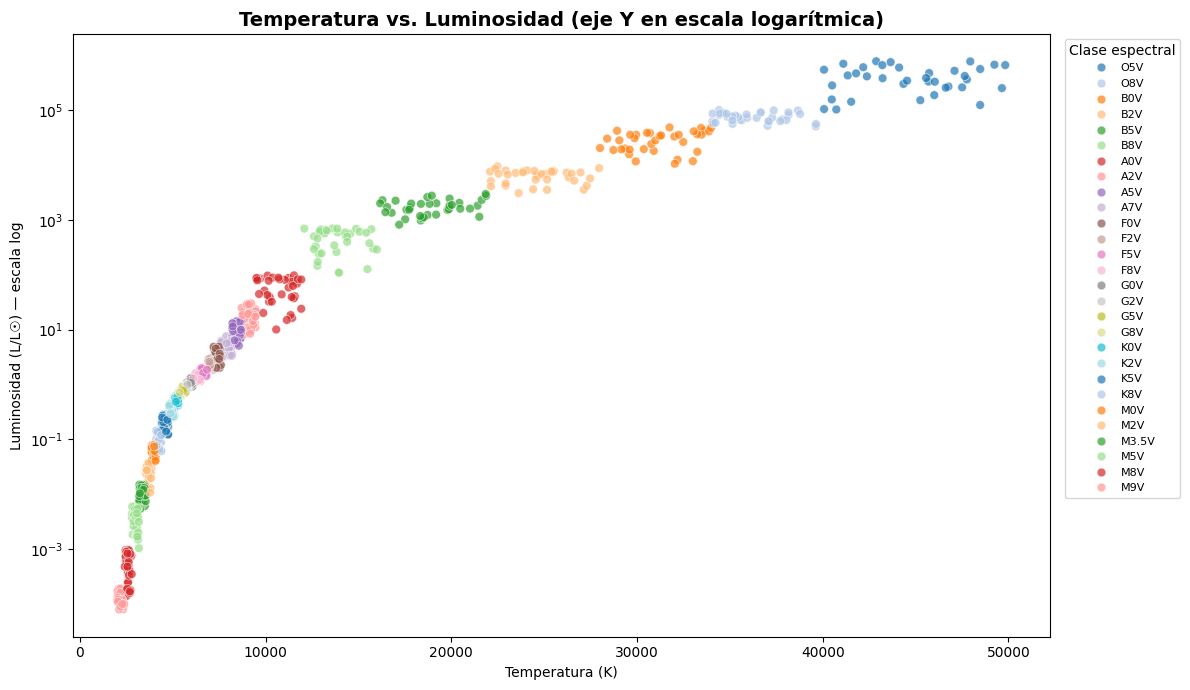

In [19]:
# ── Gráfica 3: Scatter — Temperatura vs Luminosidad (eje Y logarítmico) ─ (8 pts)
# Documentación seaborn.scatterplot: https://seaborn.pydata.org/generated/seaborn.scatterplot.html
# Documentación pyplot.yscale:       https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.yscale.html

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=stars,
    x="Temperature (K)",
    y="Luminosity (L/Lo)",
    hue="Spectral Class",
    palette="tab20",
    alpha=0.7,
    s=40
)
plt.yscale("log")   # Escala logarítmica en el eje Y
plt.title("Temperatura vs. Luminosidad (eje Y en escala logarítmica)",
          fontsize=14, fontweight="bold")
plt.xlabel("Temperatura (K)")
plt.ylabel("Luminosidad (L/L☉) — escala log")
plt.legend(title="Clase espectral", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

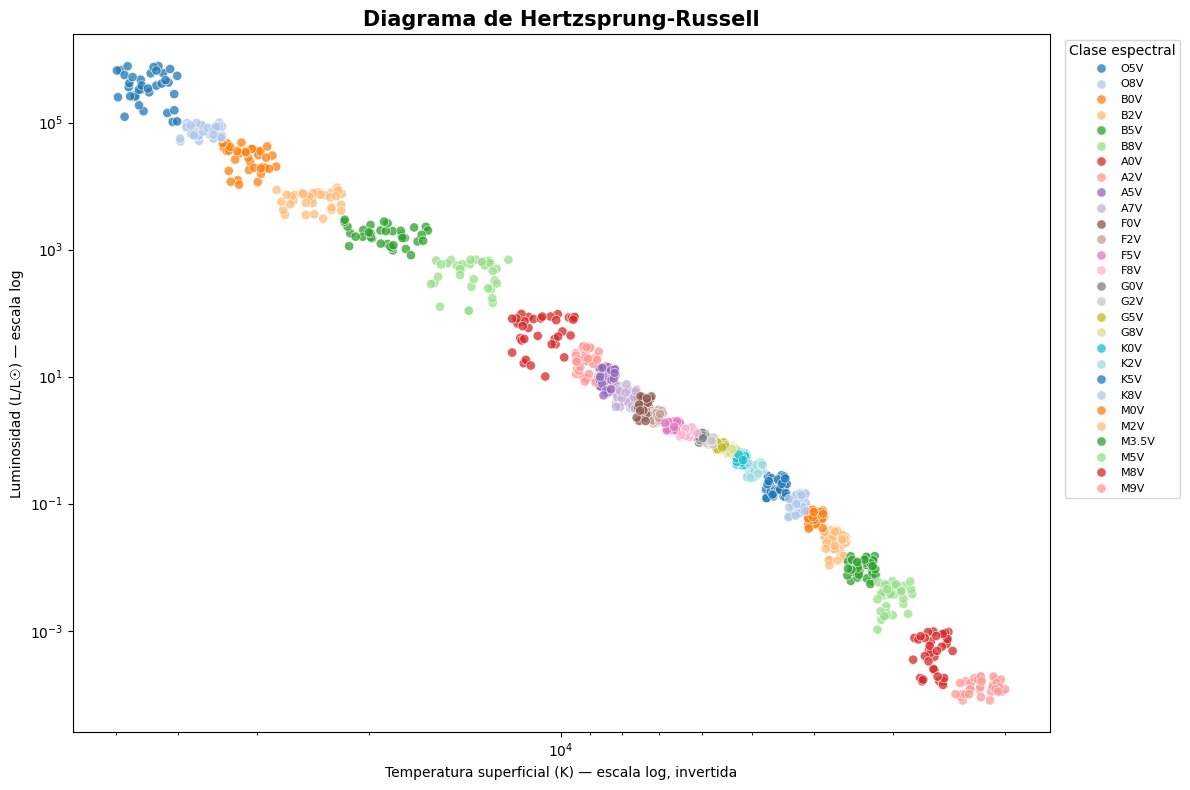

In [20]:
# ── Gráfica 4: Diagrama de Hertzsprung-Russell (HR) ──────────────────── (7 pts)
# Igual que el scatter anterior pero:
#   • Ambos ejes en escala logarítmica
#   • Eje X invertido (estrellas más calientes a la IZQUIERDA)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=stars,
    x="Temperature (K)",
    y="Luminosity (L/Lo)",
    hue="Spectral Class",
    palette="tab20",
    alpha=0.75,
    s=45
)
plt.xscale("log")           # Eje X logarítmico
plt.yscale("log")           # Eje Y logarítmico
plt.gca().invert_xaxis()    # Invertir eje X → estrellas calientes a la izquierda
plt.title("Diagrama de Hertzsprung-Russell", fontsize=15, fontweight="bold")
plt.xlabel("Temperatura superficial (K) — escala log, invertida")
plt.ylabel("Luminosidad (L/L☉) — escala log")
plt.legend(title="Clase espectral", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

---
## Sección 4 — Estadísticas vectorizadas con NumPy (20 pts)

In [21]:
# ── 1. Extraer la columna de temperaturas como array NumPy ───────────── (4 pts)
# .values convierte la Serie de Pandas en un array de NumPy

temperaturas = stars["Temperature (K)"].values

print("Tipo del objeto:")
print(type(temperaturas))

print(f"\nPrimeros 10 valores: {temperaturas[:10]}")
print(f"Forma del array    : {temperaturas.shape}")

Tipo del objeto:
<class 'numpy.ndarray'>

Primeros 10 valores: [46767.  37032.1 30695.3 22932.9 17587.1 13172.7 11432.7  8830.1  8504.6
  8155.2]
Forma del array    : (1000,)


In [22]:
# ── 2. Media, mediana y desviación estándar de la temperatura ────────── (6 pts)
# Documentación:
#   np.mean   → https://numpy.org/doc/stable/reference/generated/numpy.mean.html
#   np.median → https://numpy.org/doc/stable/reference/generated/numpy.median.html
#   np.std    → https://numpy.org/doc/stable/reference/generated/numpy.std.html

media   = np.mean(temperaturas)
mediana = np.median(temperaturas)
std     = np.std(temperaturas)

print("Estadísticas de Temperature (K):")
print(f"  Media          : {media:.2f} K")
print(f"  Mediana        : {mediana:.2f} K")
print(f"  Desv. estándar : {std:.2f} K")

Estadísticas de Temperature (K):
  Media          : 10548.11 K
  Mediana        : 6135.80 K
  Desv. estándar : 10683.16 K


In [23]:
# ── 3. Percentiles 25, 50, 75 y 90 del radio estelar ────────────────── (5 pts)
# Documentación: https://numpy.org/doc/stable/reference/generated/numpy.percentile.html

radios = stars["Radius (R/Ro)"].values

p25, p50, p75, p90 = np.percentile(radios, [25, 50, 75, 90])

print("Percentiles del radio estelar R/R☉:")
print(f"  P25 : {p25:.4f} R/R☉")
print(f"  P50 : {p50:.4f} R/R☉  (mediana)")
print(f"  P75 : {p75:.4f} R/R☉")
print(f"  P90 : {p90:.4f} R/R☉")

Percentiles del radio estelar R/R☉:
  P25 : 0.6041 R/R☉
  P50 : 0.9874 R/R☉  (mediana)
  P75 : 1.8375 R/R☉
  P90 : 5.9276 R/R☉


In [24]:
# ── 4. Conversión vectorizada de Kelvin → Celsius ────────────────────── (5 pts)
# La operación se aplica a TODOS los elementos del array de una sola vez,
# sin necesidad de un ciclo for. Esto es una operación vectorizada.

celsius = temperaturas - 273.15

print("Conversión de Kelvin a Celsius (vectorizada):")
print(f"  Tipo del resultado : {type(celsius)}")
print(f"  Forma del resultado: {celsius.shape}")
print(f"\n  Primeros 5 valores en K  : {temperaturas[:5]}")
print(f"  Primeros 5 valores en °C : {celsius[:5]}")

print(f"\n  Temperatura media en K  : {np.mean(temperaturas):.2f} K")
print(f"  Temperatura media en °C : {np.mean(celsius):.2f} °C")

# Verificación: la diferencia debe ser exactamente 273.15
diferencia = np.mean(temperaturas) - np.mean(celsius)
print(f"\n  Diferencia (debe ser 273.15): {diferencia:.2f}")

Conversión de Kelvin a Celsius (vectorizada):
  Tipo del resultado : <class 'numpy.ndarray'>
  Forma del resultado: (1000,)

  Primeros 5 valores en K  : [46767.  37032.1 30695.3 22932.9 17587.1]
  Primeros 5 valores en °C : [46493.85 36758.95 30422.15 22659.75 17313.95]

  Temperatura media en K  : 10548.11 K
  Temperatura media en °C : 10274.96 °C

  Diferencia (debe ser 273.15): 273.15


---
## Conclusiones

- El dataset contiene **1 000 estrellas** distribuidas en **28 clases espectrales** con 35-36 estrellas por clase.
- No se encontraron **valores nulos**, por lo que no fue necesario ningún preprocesamiento adicional.
- La comparación entre el **ciclo `for`** y **`groupby().mean()`** muestra que producen exactamente el mismo resultado, pero `groupby` es más conciso, legible y eficiente para grandes volúmenes de datos.
- Las **operaciones vectorizadas de NumPy** (como `temperaturas - 273.15`) son más rápidas que los ciclos porque operan a nivel de C internamente.
- El **Diagrama HR** muestra claramente la secuencia principal: las estrellas tipo O/B (calientes, luminosas) en la esquina superior izquierda, y las M (frías, tenues) en la inferior derecha.
- La **escala logarítmica** es indispensable para visualizar la luminosidad, que varía en más de 10 órdenes de magnitud en el dataset.